# Import Libs

In [1]:
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler , OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error , r2_score
from sklearn.ensemble import VotingRegressor
from sklearn.tree import plot_tree

# EDA

In [2]:
df = pd.read_csv("/kaggle/input/datasets/mirichoi0218/insurance/insurance.csv")

In [3]:
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [4]:
df["region"].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [7]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [8]:
df[["age" , "bmi" , "children","charges"]].corr()

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


# Train Test Split

In [9]:
#region --> ohe
#smoker , sex --> manuel mapping

sex_map = {"male" : 0 , "female" : 1}
df["sex"] = df["sex"].map(sex_map)

smoker_map = {"no" : 0 , "yes" : 1}
df["smoker"] = df["smoker"].map(smoker_map)

X = df[["age" , "bmi" , "children","sex","smoker","region"]]
y = df["charges"]

X_train , X_test , y_train , y_test = train_test_split (X , y , test_size = 0.25 , random_state = 42)

# Scaling & Encoding

In [10]:
scaler = StandardScaler()
scale_cols = ["age","bmi","children"] 

X_train_scaled = scaler.fit_transform( X_train[scale_cols] )
X_test_scaled  =scaler.transform( X_test[scale_cols] )


ohe = OneHotEncoder( handle_unknown = "ignore" , sparse_output = False , drop = "first")
X_train_encoding = ohe.fit_transform(X_train[["region"]])
X_test_encoding  = ohe.transform(X_test[["region"]])

X_train_others = X_train[["sex" ,"smoker"]].values
X_test_others = X_test[["sex" ,"smoker"]].values

X_train_final = np.hstack([X_train_scaled , X_train_encoding , X_train_others])
X_test_final = np.hstack([X_test_scaled , X_test_encoding , X_test_others])

# Modelling (Decision Tree And Linear Regression)

In [11]:
linear_model = LinearRegression()
linear_model.fit(X_train_final , y_train)

y_pred_linear = linear_model.predict(X_test_final)

mse_linear = mean_squared_error( y_test , y_pred_linear )
r2_linear = r2_score(y_test , y_pred_linear )

dt_model = DecisionTreeRegressor(max_depth = 6 , 
                                 min_samples_split = 4 , # Bir düğümü bölmek için gereken minimum örnek
                                 min_samples_leaf=2 , # Bir yaprak düğümünde bulunabilecek minimum örnek.
                                 max_features = 5, # Her bölünmede göz önünde bulundurulacak öznitelik sayısı
                                 random_state = 42
                                )

dt_model.fit( X_train_final , y_train )

y_pred_dt = dt_model.predict(X_test_final)

mse_dt = mean_squared_error(y_test , y_pred_dt)

r2_dt = r2_score (y_test , y_pred_dt)

ensemble_model = VotingRegressor([
    ("lr" , linear_model ),
    ("dt" , dt_model)
])

ensemble_model.fit(X_train_final, y_train)

y_pred_ensemble = ensemble_model.predict(X_test_final)

mse_ens = mean_squared_error(y_test , y_pred_ensemble)

r2_ens = r2_score (y_test , y_pred_ensemble)

print(f"Linear MSE : {mse_linear}")
print(f"Linear RMSE : {np.sqrt(mse_linear)}")
print(f"Linear R2  : {r2_linear}")

print()

print(f"DT MSE : {mse_dt}")
print(f"DT RMSE : {np.sqrt(mse_dt)}")
print(f"DT R2  : {r2_dt}")

print()

print(f"Ensemble MSE : {mse_ens}")
print(f"Ensemble RMSE : {np.sqrt(mse_ens)}")
print(f"Ensemble R2  : {r2_ens}")

Linear MSE : 35117755.73613631
Linear RMSE : 5926.023602394468
Linear R2  : 0.7672642952734358

DT MSE : 20699685.906696472
DT RMSE : 4549.690748468128
DT R2  : 0.8628170882185319

Ensemble MSE : 23789401.343572553
Ensemble RMSE : 4877.43798972089
Ensemble R2  : 0.8423406345120681


# Visualization

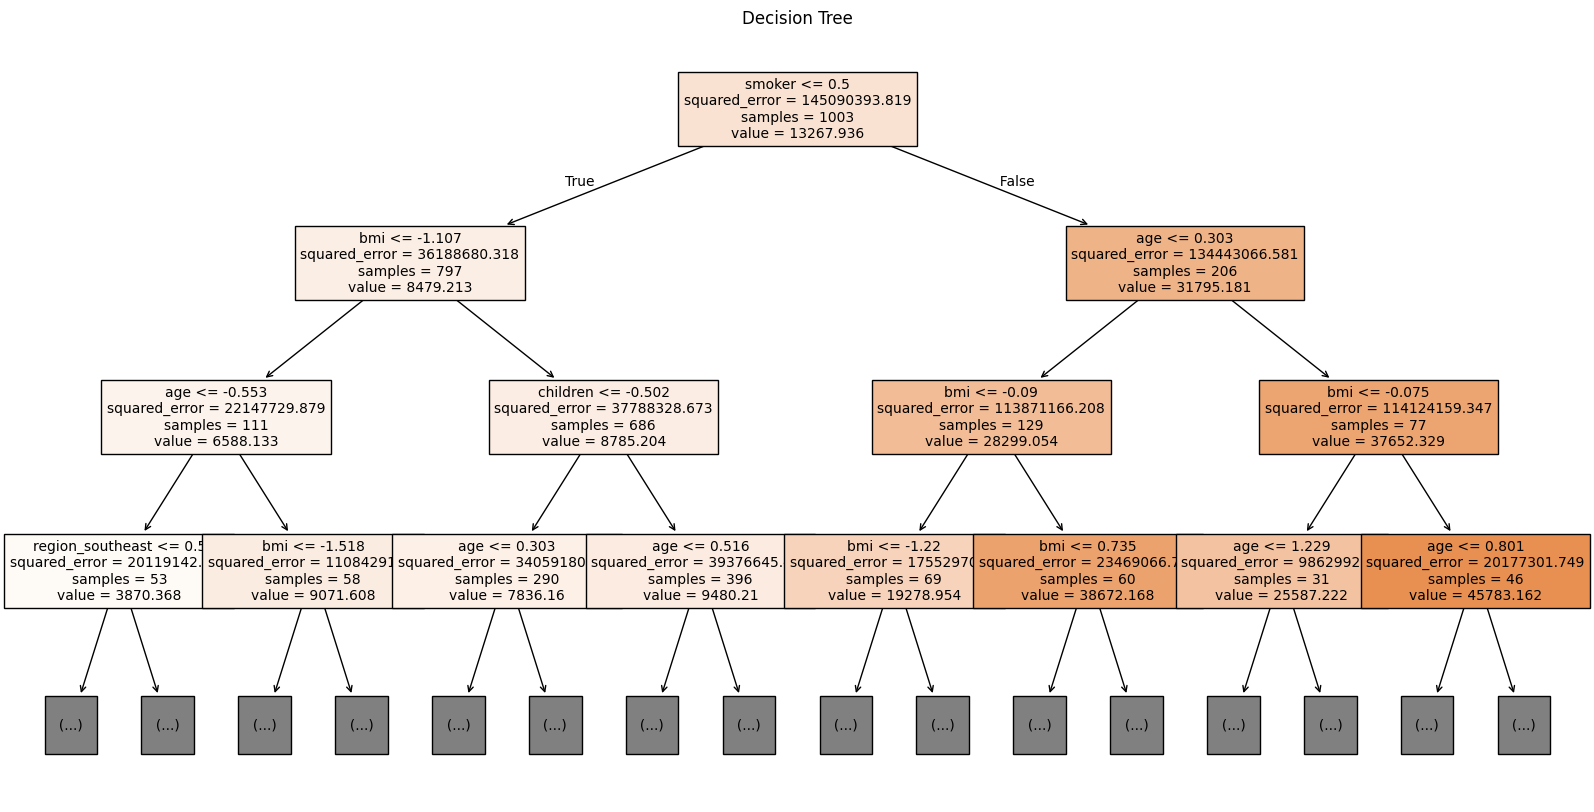

In [12]:
plt.figure(figsize=(20, 10))

cols = []

plot_tree(dt_model, 
          feature_names= scale_cols + list(ohe.get_feature_names_out()) + ["sex", "smoker"],
          filled=True,     
          max_depth=3,     
          fontsize=10)

plt.title("Decision Tree")
plt.show()